In [1]:
import ROOT
# import uproot as up
# import numpy as np

Welcome to JupyROOT 6.26/10


In [2]:
# Open ROOT file
# file_path = "/uscms/home/wkarunar/nobackup/datasets/data/crab_TTree_136TeV_PDMLM0_mm_2023D_vTest_roundedInt.root"
file_path = "output_data.root"
file = ROOT.TFile(file_path)
tree = file.Get("ntuple")

In [3]:
tree.GetEntries()

33060

In [4]:
J_Mass = ROOT.RooRealVar("B_J1_mass", "J/psi Mass", 2.7, 3.5, "GeV")
Run = ROOT.RooRealVar("Run", "Run", 0, 1e6)
LumiBlock = ROOT.RooRealVar("LumiBlock", "LumiBlock", 0, 1e6)
mu1_pt = ROOT.RooRealVar("B_Mu1_pt", "Muon 1 pT", 7, 1000, "GeV")
mu2_pt = ROOT.RooRealVar("B_Mu2_pt", "Muon 2 pT", 7, 1000, "GeV")

# Include all variables referenced in the cut in the RooArgSet
var_set = ROOT.RooArgSet(J_Mass, Run, LumiBlock, mu1_pt, mu2_pt)

# Define cut string
cut_str = "(Run == 370097) && (LumiBlock >= 150) && (LumiBlock < 200)"

# Create the dataset with the cut
data = ROOT.RooDataSet("data", "dataset", tree, var_set, cut_str)

print("Entries after cut:", data.numEntries())

Entries after cut: 33060
[#1] INFO:DataHandling -- RooAbsReal::attachToTree(B_J1_mass) TTree Float_t branch B_J1_mass will be converted to double precision.
[#1] INFO:DataHandling -- RooAbsReal::attachToTree(Run) TTree Float_t branch Run will be converted to double precision.
[#1] INFO:DataHandling -- RooAbsReal::attachToTree(LumiBlock) TTree Float_t branch LumiBlock will be converted to double precision.
[#1] INFO:DataHandling -- RooAbsReal::attachToTree(B_Mu1_pt) TTree Float_t branch B_Mu1_pt will be converted to double precision.
[#1] INFO:DataHandling -- RooAbsReal::attachToTree(B_Mu2_pt) TTree Float_t branch B_Mu2_pt will be converted to double precision.


In [5]:
# import array

# # Assume your RooDataSet is called `data`
# output_file = ROOT.TFile("output_data.root", "RECREATE")
# tree = ROOT.TTree("ntuple", "Reduced RooDataSet as TTree")

# # Prepare branches and buffer arrays
# variables = data.get()  # RooArgSet of all observables
# buffers = {}

# for var in variables:
#     name = var.GetName()
#     buffers[name] = array.array('f', [0.])  # 'f' = float, one-element array
#     tree.Branch(name, buffers[name], f"{name}/F")  # 'F' = float branch

# # Loop over dataset entries and fill TTree
# for i in range(data.numEntries()):
#     vars_i = data.get(i)
#     for var in variables:
#         name = var.GetName()
#         buffers[name][0] = vars_i[name].getVal()
#     tree.Fill()

# # Save the file
# tree.Write()
# output_file.Close()

In [6]:
nEntries = data.numEntries()

In [7]:
# ########## Model 1: Double Gaussian + Polynomial Background ##########
# # Define double Gaussian signal model
# mean = ROOT.RooRealVar("mean", "Mean of Gaussians", 3.1, 3.0, 3.2)
# sigma1 = ROOT.RooRealVar("sigma1", "Width of Gaussian 1", 0.02, 0.001, 0.1)
# sigma2 = ROOT.RooRealVar("sigma2", "Width of Gaussian 2", 0.05, 0.001, 0.1)
# gauss1 = ROOT.RooGaussian("gauss1", "Gaussian 1", J_Mass, mean, sigma1)
# gauss2 = ROOT.RooGaussian("gauss2", "Gaussian 2", J_Mass, mean, sigma2)
# frac = ROOT.RooRealVar("frac", "Fraction of Gauss1", 0.5, 0.0, 1.0)
# signal = ROOT.RooAddPdf("signal", "Double Gaussian", ROOT.RooArgList(gauss1, gauss2), ROOT.RooArgList(frac))

# # Define background model (2nd degree polynomial)
# a0 = ROOT.RooRealVar("a0", "a0", 0.0, -1.0, 1.0)
# a1 = ROOT.RooRealVar("a1", "a1", 0.0, -1.0, 1.0)
# background = ROOT.RooPolynomial("background", "polynomial", J_Mass, ROOT.RooArgList(a0, a1))

# # Combine signal and background
# nsig = ROOT.RooRealVar("nsig", "Number of signal events", nEntries/2, 0, nEntries*2)
# nbkg = ROOT.RooRealVar("nbkg", "Number of background events", nEntries/2, 0, nEntries*2)

# model = ROOT.RooAddPdf("model", "Signal + Background", 
#                         ROOT.RooArgList(signal, background),
#                         ROOT.RooArgList(nsig, nbkg))
# ############ END Model 1 ##########

In [8]:
########### Model 2: CB + Gaussian + Polynomial Background ##########
mean = ROOT.RooRealVar("mean", "Mean", 3.09, 2.7, 3.5)
sigma = ROOT.RooRealVar("sigma", "Sigma", 0.02, 0.001, 0.1)
alpha = ROOT.RooRealVar("alpha", "Alpha (Tail Slope)", 1.53, 0.5, 5.0)
n = ROOT.RooRealVar("n", "n (Tail Exponent)", 3, 1, 10)
cb = ROOT.RooCrystalBall("cb", "Crystal Ball", J_Mass, mean, sigma, alpha, n)

sigma2 = ROOT.RooRealVar("sigma2", "Width of Gaussian 2", 0.04, 0.01, 0.1)
gauss2 = ROOT.RooGaussian("gauss2", "Gaussian 2", J_Mass, mean, sigma2)

frac = ROOT.RooRealVar("frac", "Fraction of Gauss2", 0.7, 0.0, 1.0)
signal = ROOT.RooAddPdf("signal", "CB + Gaussian", ROOT.RooArgList(cb, gauss2), ROOT.RooArgList(frac))

# Define background model (2nd degree polynomial)
c0 = ROOT.RooRealVar("c0", "c0", -0.1, -1., 0)
background = ROOT.RooChebychev("background", "Polynomial Background", J_Mass, ROOT.RooArgList(c0))

# Combine signal and background
# nsig = ROOT.RooRealVar("nsig", "Number of signal events", nEntries/2, 0, nEntries*2)
# nbkg = ROOT.RooRealVar("nbkg", "Number of background events", nEntries/2, 0, nEntries*2)
sigFrac = ROOT.RooRealVar("sigFrac", "Signal Fraction", 0.7, 0.0, 1.0)

model = ROOT.RooAddPdf("model", "Signal + Background",
                     ROOT.RooArgList(signal, background),
                     ROOT.RooArgList(sigFrac))
############# END Model 2 ##########

In [9]:
# Perform fit Extended
result = model.fitTo(data, ROOT.RooFit.Save(True), ROOT.RooFit.Minimizer("Minuit2", "migradimproved"), ROOT.RooFit.NumCPU(4))
# result = model.fitTo(data, ROOT.RooFit.Save(True), ROOT.RooFit.Minimizer("Minuit2")) #ROOT.RooFit.NumCPU(4))

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Eval -- RooAbsTestStatistic::initMPMode: started 4 remote server process.
Minuit2Minimizer: Minimize with max-calls 4000 convergence for edm < 1 strategy 1
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb,gauss2,background)
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb,gauss2,background)
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb,gauss2,background)
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (cb,gauss2,background)
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = -44887.4819489256843
Edm   = 0.000120643040441266225
Nfcn  = 537
alpha	  = 1.98369	 +/-  0.0652935	(limited)
c0	  = -0.535626	 +/-  0.0278132	(limited)
frac	  = 0.545604	 +/-  0.0325946	(limited)
mean	  = 3.093

Info in <Minuit2>: MnSeedGenerator Initial state: FCN =      -43317.01425 Edm =       1276.001234 NCalls =     33
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -43573.43547
  Edm           : 1516.640259
  Internal parameters:
    -0.5730796217
    -0.3513638054
     0.4115168461
    -0.0250026049
    -0.5890309702
     0.4115168461
    -0.6638599611
    -0.3398369095
  Internal gradient  :
     -363.2149215
     -83.03138183
      1213.742669
      -48259.7776
     -227.4000023
     -4991.385744
     -4413.393702
     -622.6994047
  Internal covariance matrix:
  0.00045219994              0              0              0              0              0              0              0
              0   0.0031931023              0              0              0              0              0              0
              0              0  0.00086835472              0              0              0              0              0
              0              0 

[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) directly selected PDF components: (background)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) indirectly selected PDF components: ()
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) directly selected PDF components: (signal)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) indirectly selected PDF components: (cb,gauss2)


Info in <TCanvas::Print>: png file fit_result.png has been created


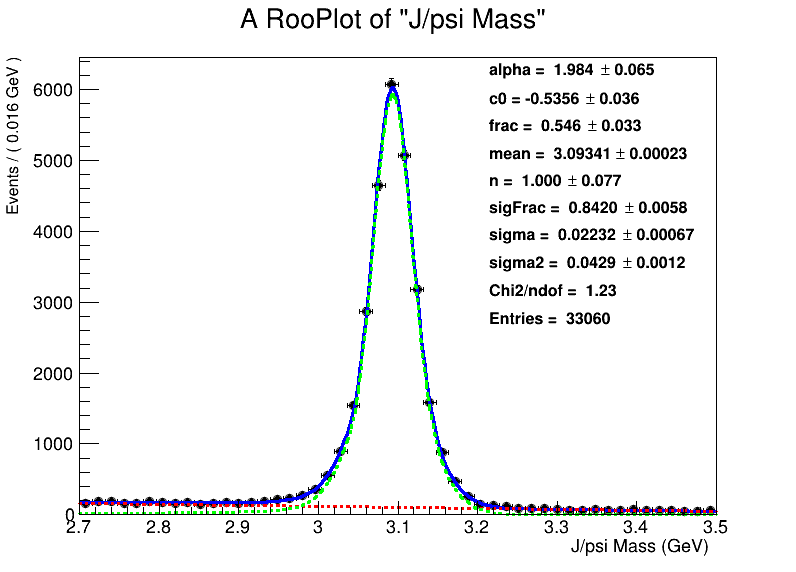

In [10]:
# Plot results
c1 = ROOT.TCanvas("c1", "Fit", 800, 600)
frame = J_Mass.frame()
data.plotOn(frame, ROOT.RooFit.Name('dataset'), ROOT.RooFit.Binning(50))
model.plotOn(frame ,ROOT.RooFit.Name('model'))
model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

chi2 = frame.chiSquare("model", "dataset", 7)

# Stat box
model.paramOn(frame, ROOT.RooFit.Layout(0.6, 0.9, 0.9))
frame.getAttText().SetTextSize(0.03)
frame.GetYaxis().SetTitleSize(0.03)
frame.GetYaxis().SetTitleOffset(1.7)
pt = frame.findObject("model_paramBox")
pt.AddText(ROOT.Form(f"Chi2/ndof =  {chi2:.2f}"))
pt.AddText(ROOT.Form("Entries =  {0:.0f}".format(data.numEntries())))

frame.Draw()
c1.SaveAs("fit_result.png")

# Keep the canvas open
c1.Draw()